# 📖 Chương 1: Vĩ mô & Sự phân hóa Kinh tế toàn cầu
*Mục đích: Thiết lập bối cảnh chung về sự bùng nổ của nhân loại trong hơn 6 thập kỷ qua, đồng thời bóc tách sự bất bình đẳng giữa các nhóm quốc gia dựa trên mức thu nhập.*

In [10]:
# Import thư viện
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

# Cấu hình style cho biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# Load dữ liệu đã làm sạch
df = pd.read_parquet('../../data/wdi_cleaned.parquet')

## 1. Cú nhảy vọt của kinh tế toàn cầu (1960 - Nay)
Chúng ta sẽ bắt đầu bức tranh với một câu hỏi vĩ mô nhất: **Nhân loại đã tạo ra bao nhiêu của cải kể từ năm 1960?** Dù trải qua nhiều biến cố lịch sử, chiến tranh và dịch bệnh, đường cong GDP của thế giới mang trong mình một sức bật đáng kinh ngạc. Hãy cùng xem các sự kiện như Khủng hoảng tài chính 2008 hay Đại dịch COVID-19 2020 đã để lại "vết sẹo" như thế nào trên biểu đồ này.

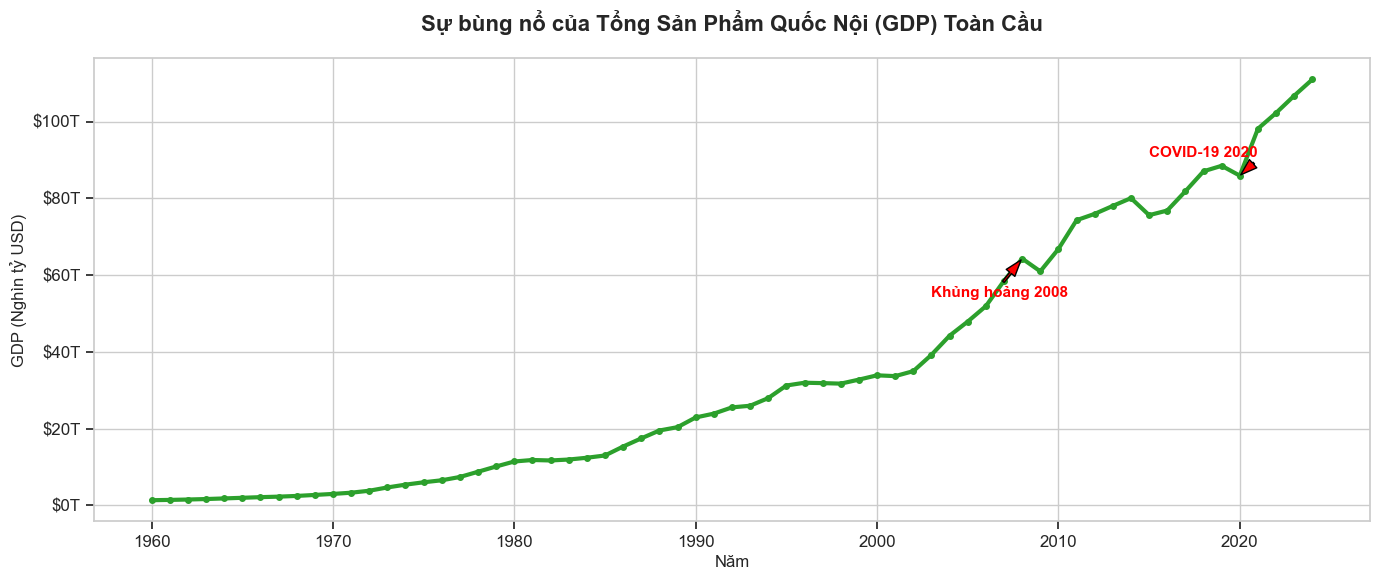


💡 **Góc nhìn (Data Insight):**
* Khởi điểm năm 1960, quy mô kinh tế toàn cầu chỉ ở mức **~$1.37 nghìn tỷ USD**.
* Đến năm 2024, con số này đã đạt **~$110.98 nghìn tỷ USD**, tức là quy mô nền kinh tế nhân loại đã phình to gấp **81 lần**.
* Dù các cú sốc như 2008 hay 2020 tạo ra những nhịp điều chỉnh giảm rõ rệt, xu hướng phục hồi sau đó luôn diễn ra theo đồ thị dốc đứng.


In [2]:
# Tiền xử lý dữ liệu cho GDP Toàn cầu (Dùng Country Code là 'WLD' cho World)
df_world_gdp = df[(df['Country Code'] == 'WLD') & 
                  (df['Indicator Code'] == 'NY.GDP.MKTP.CD')].copy()

# Sắp xếp theo năm
df_world_gdp = df_world_gdp.sort_values('Year')

# Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_world_gdp['Year'], df_world_gdp['Value'], color='#2ca02c', linewidth=3, marker='o', markersize=4)

# Định dạng trục Y thành Nghìn tỷ USD (Trillions)
formatter = ticker.FuncFormatter(lambda x, pos: f'${x*1e-12:,.0f}T')
ax.yaxis.set_major_formatter(formatter)

# Highlight các sự kiện lịch sử
events = {
    2008: ("Khủng hoảng 2008", -1e13),
    2020: ("COVID-19 2020", 0.5e13)
}

for year, (label, offset) in events.items():
    if year in df_world_gdp['Year'].values:
        val = df_world_gdp[df_world_gdp['Year'] == year]['Value'].values[0]
        ax.annotate(label, xy=(year, val), xytext=(year - 5, val + offset),
                    arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
                    fontsize=11, color='red', weight='bold')

plt.title('Sự bùng nổ của Tổng Sản Phẩm Quốc Nội (GDP) Toàn Cầu', fontsize=16, weight='bold', pad=20)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('GDP (Nghìn tỷ USD)', fontsize=12)
plt.tight_layout()
plt.show()

# --- Tạo Insight động bằng Markdown ---
gdp_1960 = df_world_gdp[df_world_gdp['Year'] == df_world_gdp['Year'].min()]['Value'].values[0]
gdp_latest = df_world_gdp[df_world_gdp['Year'] == df_world_gdp['Year'].max()]['Value'].values[0]
latest_year = df_world_gdp['Year'].max()
growth_multiplier = gdp_latest / gdp_1960

insight_1 = f"""
💡 **Góc nhìn (Data Insight):**
* Khởi điểm năm 1960, quy mô kinh tế toàn cầu chỉ ở mức **~${gdp_1960*1e-12:,.2f} nghìn tỷ USD**.
* Đến năm {latest_year}, con số này đã đạt **~${gdp_latest*1e-12:,.2f} nghìn tỷ USD**, tức là quy mô nền kinh tế nhân loại đã phình to gấp **{growth_multiplier:.0f} lần**.
* Dù các cú sốc như 2008 hay 2020 tạo ra những nhịp điều chỉnh giảm rõ rệt, xu hướng phục hồi sau đó luôn diễn ra theo đồ thị dốc đứng.
"""
display(Markdown(insight_1))

## 2. Dịch chuyển trọng tâm nhân khẩu học
Của cải tăng lên, vậy còn con người thì sao? Trái đất đang chật chội hơn, nhưng sự gia tăng này không phân bố đồng đều. 
Biểu đồ miền xếp chồng (Stacked Area Chart) dưới đây sẽ cho ta thấy rõ sự bùng nổ dân số chủ yếu diễn ra ở đâu, và lục địa nào đang có dấu hiệu "chững lại" về mặt nhân khẩu học.

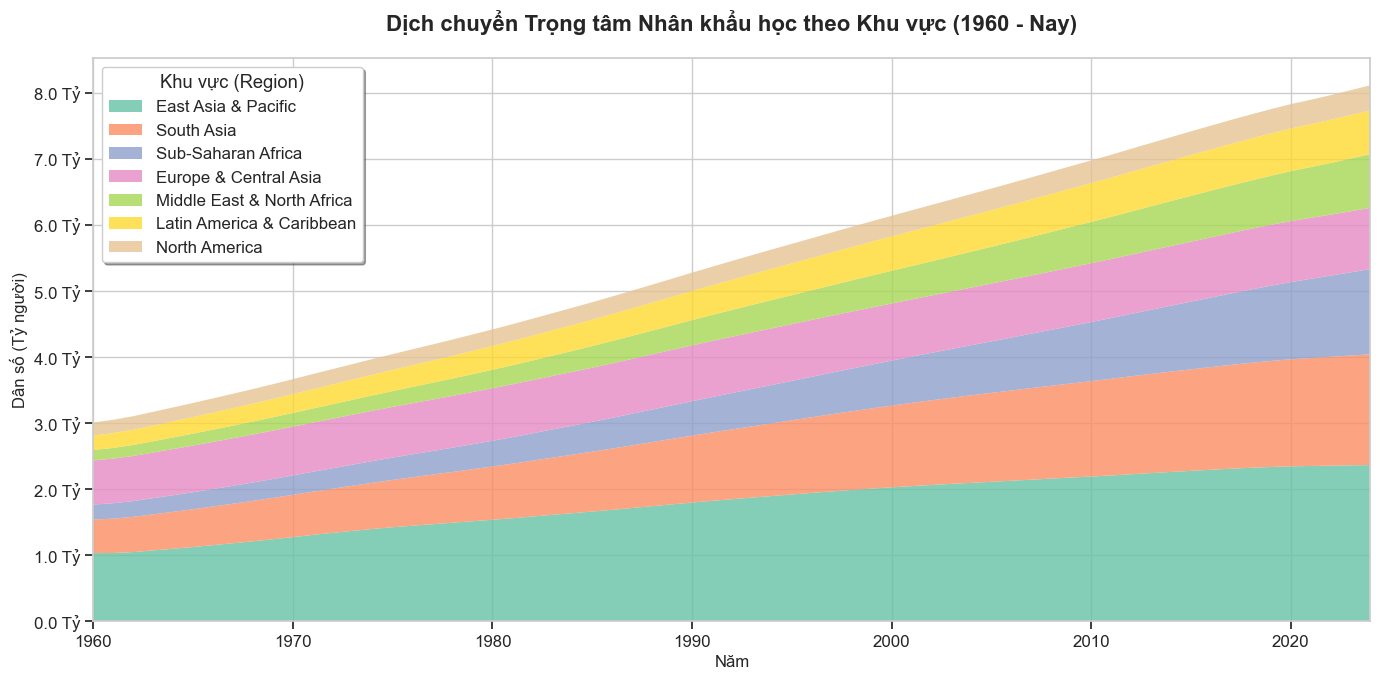


💡 **Góc nhìn (Data Insight):**
* **Châu Á vươn mình:** Khối Đông Á & Thái Bình Dương cùng với Nam Á đóng góp phần lớn nhất vào sự bùng nổ dân số toàn cầu, chiếm khoảng **49.8%** tổng dân số hiện tại.
* **Động lực mới từ Châu Phi:** Vùng Sub-Saharan Africa có độ dốc (tốc độ tăng trưởng) cao nhất trong 2 thập kỷ gần đây, hứa hẹn là nguồn cung lao động chính của thế giới trong tương lai.
* **Châu Âu & Bắc Mỹ chững lại:** Trái ngược với mảng màu mở rộng liên tục của Châu Á và Phi, dải màu của Châu Âu và Trung Á (Europe & Central Asia) gần như duy trì độ dày không đổi từ những năm 1990, phản ánh tình trạng già hóa dân số.


In [3]:
# Lọc dữ liệu dân số (SP.POP.TOTL) và chỉ lấy các quốc gia có phân loại Region (loại bỏ các dòng aggregate như World, Income Group...)
df_pop = df[(df['Indicator Code'] == 'SP.POP.TOTL') & (df['Region'].notnull())]

# Group by Năm và Region
pop_region = df_pop.groupby(['Year', 'Region'])['Value'].sum().unstack()

# Sắp xếp các cột dựa trên dân số năm mới nhất để hiển thị đẹp hơn
latest_year_pop = pop_region.iloc[-1].sort_values(ascending=False)
pop_region = pop_region[latest_year_pop.index]

# Vẽ biểu đồ Stacked Area
fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette("Set2", n_colors=len(pop_region.columns))

ax.stackplot(pop_region.index, pop_region.T, labels=pop_region.columns, colors=colors, alpha=0.8)

# Định dạng trục Y thành Tỷ người (Billions)
formatter_pop = ticker.FuncFormatter(lambda x, pos: f'{x*1e-9:,.1f} Tỷ')
ax.yaxis.set_major_formatter(formatter_pop)

plt.title('Dịch chuyển Trọng tâm Nhân khẩu học theo Khu vực (1960 - Nay)', fontsize=16, weight='bold', pad=20)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Dân số (Tỷ người)', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True, title='Khu vực (Region)')
plt.margins(x=0)
plt.tight_layout()
plt.show()

# --- Tạo Insight động bằng Markdown ---
asia_pop_latest = pop_region['East Asia & Pacific'].iloc[-1] + pop_region['South Asia'].iloc[-1]
africa_pop_latest = pop_region['Sub-Saharan Africa'].iloc[-1] + pop_region['Middle East & North Africa'].iloc[-1]
total_pop = pop_region.iloc[-1].sum()

insight_2 = f"""
💡 **Góc nhìn (Data Insight):**
* **Châu Á vươn mình:** Khối Đông Á & Thái Bình Dương cùng với Nam Á đóng góp phần lớn nhất vào sự bùng nổ dân số toàn cầu, chiếm khoảng **{(asia_pop_latest/total_pop)*100:.1f}%** tổng dân số hiện tại.
* **Động lực mới từ Châu Phi:** Vùng Sub-Saharan Africa có độ dốc (tốc độ tăng trưởng) cao nhất trong 2 thập kỷ gần đây, hứa hẹn là nguồn cung lao động chính của thế giới trong tương lai.
* **Châu Âu & Bắc Mỹ chững lại:** Trái ngược với mảng màu mở rộng liên tục của Châu Á và Phi, dải màu của Châu Âu và Trung Á (Europe & Central Asia) gần như duy trì độ dày không đổi từ những năm 1990, phản ánh tình trạng già hóa dân số.
"""
display(Markdown(insight_2))

## 3. Bức tường giàu nghèo (The Wealth Gap)
Chúng ta đã thấy GDP tăng, dân số tăng. Nhưng **"Của cải có chảy về nơi đông người không?"**
Để trả lời, chúng ta sẽ so sánh tỷ trọng Dân số và tỷ trọng GDP toàn cầu được đóng góp bởi các Nhóm thu nhập (Income Group). Sự chênh lệch giữa hai biểu đồ Donut này chính là định nghĩa trực quan nhất về sự bất bình đẳng.

> ⚠️ **Lưu ý:** Năm `2025` chưa có (hoặc chưa đủ) dữ liệu tổng hợp từ World Bank. Hệ thống đang tự động tìm năm gần nhất...

> ✅ **Đã tự động chuyển sang năm:** `2024`

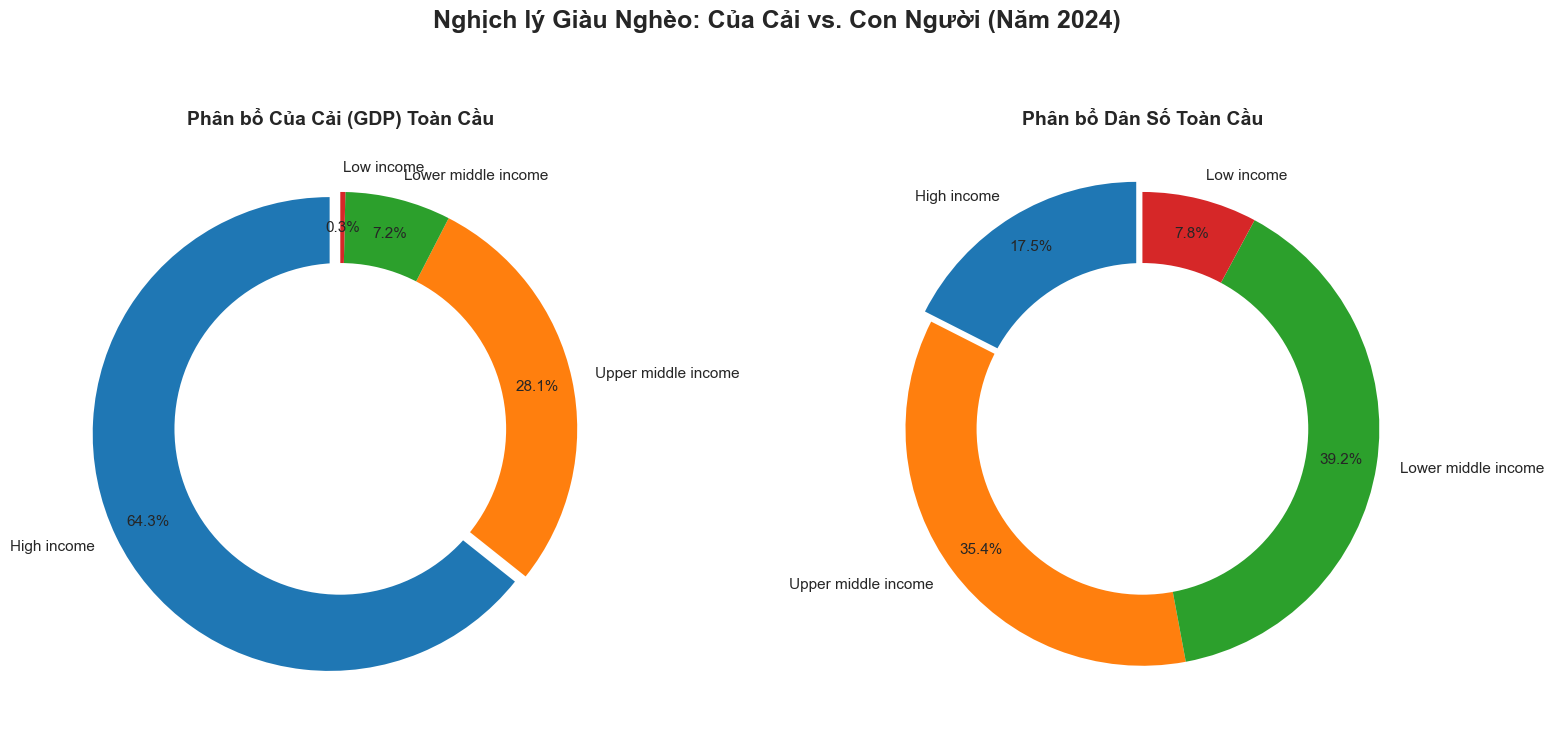


💡 **Góc nhìn (Data Insight năm 2024):**
Sự mất cân đối hiển thị cực kỳ gay gắt khi ta đối chiếu hai lăng kính:
* **Đặc quyền của nhóm High Income:** Dù chỉ chiếm khoảng **17.5%** dân số thế giới, nhưng nhóm quốc gia Thu nhập cao lại đang nắm giữ tới **64.3%** tổng tài sản (GDP) toàn cầu.
* **Sự chật vật của nhóm Low Income:** Ngược lại, những quốc gia thuộc nhóm Thu nhập thấp chiếm **7.8%** dân số nhân loại, nhưng chiếc bánh kinh tế họ được chia chỉ vỏn vẹn **0.3%**.
👉 *Bức tường giàu nghèo này chính là tiền đề dẫn chúng ta đến Chương 2: Đánh giá tác động của thu nhập lên tuổi thọ và chất lượng sống.*


In [ ]:
# 1. Cài đặt năm muốn phân tích
target_year = 2025

# Lọc khoanh vùng dữ liệu trước
indicators = ['NY.GDP.MKTP.CD', 'SP.POP.TOTL']
df_subset = df[(df['Indicator Code'].isin(indicators)) & (df['Income Group'].notnull())]

# 2. Kiểm tra dữ liệu của target_year
df_gap = df_subset[df_subset['Year'] == target_year]

# Nếu năm này không có dữ liệu hoặc không đủ 2 chỉ số (GDP và Dân số)
if df_gap.empty or len(df_gap['Indicator Code'].unique()) < 2:
    display(Markdown(f"> ⚠️ **Lưu ý:** Năm `{target_year}` chưa có (hoặc chưa đủ) dữ liệu tổng hợp từ World Bank. Hệ thống đang tự động tìm năm gần nhất..."))
    
    # Tìm năm lớn nhất mà có đủ cả 2 loại Indicator
    valid_years = df_subset.groupby('Year')['Indicator Code'].nunique()
    target_year = valid_years[valid_years == 2].index.max()
    
    display(Markdown(f"> ✅ **Đã tự động chuyển sang năm:** `{target_year}`"))
    
    # Lọc lại dữ liệu theo năm hợp lệ
    df_gap = df_subset[df_subset['Year'] == target_year]

# 3. Pivot table
df_pivot = df_gap.pivot_table(index='Income Group', columns='Indicator Code', values='Value', aggfunc='sum')

# Đổi tên cột một cách an toàn thay vì ghi đè bằng list
df_pivot = df_pivot.rename(columns={
    'NY.GDP.MKTP.CD': 'GDP', 
    'SP.POP.TOTL': 'Population'
})

# Sắp xếp lại thứ tự Income Group cho logic
income_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
# Chỉ giữ lại các index có tồn tại để tránh lỗi
existing_indices = [idx for idx in income_order if idx in df_pivot.index]
df_pivot = df_pivot.reindex(existing_indices)

# 4. Vẽ Dual Donut Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
colors_pie = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
explode = (0.05, 0, 0, 0) # Tách nhẹ High Income ra

# Biểu đồ 1: Tỷ trọng GDP
ax1.pie(df_pivot['GDP'], labels=df_pivot.index, autopct='%1.1f%%', startangle=90, 
        colors=colors_pie, explode=explode, pctdistance=0.85, textprops={'fontsize': 11})
centre_circle1 = plt.Circle((0,0), 0.70, fc='white')
ax1.add_artist(centre_circle1)
ax1.set_title('Phân bổ Của Cải (GDP) Toàn Cầu', fontsize=14, weight='bold')

# Biểu đồ 2: Tỷ trọng Dân số
ax2.pie(df_pivot['Population'], labels=df_pivot.index, autopct='%1.1f%%', startangle=90, 
        colors=colors_pie, explode=explode, pctdistance=0.85, textprops={'fontsize': 11})
centre_circle2 = plt.Circle((0,0), 0.70, fc='white')
ax2.add_artist(centre_circle2)
ax2.set_title('Phân bổ Dân Số Toàn Cầu', fontsize=14, weight='bold')

plt.suptitle(f'Nghịch lý Giàu Nghèo: Của Cải vs. Con Người (Năm {target_year})', fontsize=18, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

# --- 5. Tạo Insight động bằng Markdown ---
high_income_gdp_pct = (df_pivot.loc['High income', 'GDP'] / df_pivot['GDP'].sum()) * 100
high_income_pop_pct = (df_pivot.loc['High income', 'Population'] / df_pivot['Population'].sum()) * 100

low_income_gdp_pct = (df_pivot.loc['Low income', 'GDP'] / df_pivot['GDP'].sum()) * 100
low_income_pop_pct = (df_pivot.loc['Low income', 'Population'] / df_pivot['Population'].sum()) * 100

insight_3 = f"""
💡 **Góc nhìn (Data Insight năm {target_year}):**
Sự mất cân đối hiển thị cực kỳ gay gắt khi ta đối chiếu hai lăng kính:
* **Đặc quyền của nhóm High Income:** Dù chỉ chiếm khoảng **{high_income_pop_pct:.1f}%** dân số thế giới, nhưng nhóm quốc gia Thu nhập cao lại đang nắm giữ tới **{high_income_gdp_pct:.1f}%** tổng tài sản (GDP) toàn cầu.
* **Sự chật vật của nhóm Low Income:** Ngược lại, những quốc gia thuộc nhóm Thu nhập thấp chiếm **{low_income_pop_pct:.1f}%** dân số nhân loại, nhưng chiếc bánh kinh tế họ được chia chỉ vỏn vẹn **{low_income_gdp_pct:.1f}%**.
👉 *Bức tường giàu nghèo này chính là tiền đề dẫn chúng ta đến Chương 2: Đánh giá tác động của thu nhập lên tuổi thọ và chất lượng sống.*
"""
display(Markdown(insight_3))